In [1]:
!pip install tensorflow
!pip install matplotlib

In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np

In [3]:
# Load Dataset (same as your code)
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

# Normalize
x_train = x_train / 255.0
x_test = x_test / 255.0

# Add channel dimension
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


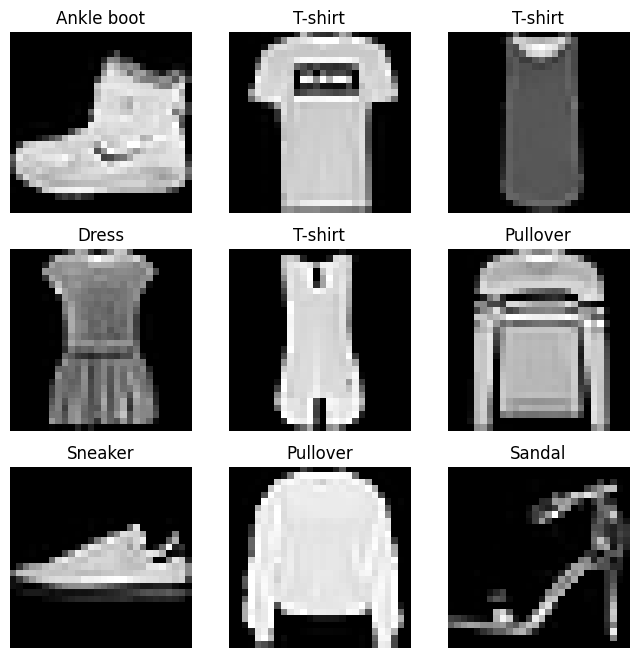

In [4]:
class_names = ['T-shirt','Trouser','Pullover','Dress','Coat',
               'Sandal','Shirt','Sneaker','Bag','Ankle boot']

# Show sample images
plt.figure(figsize=(8,8))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(x_train[i].reshape(28,28), cmap='gray')
    plt.title(class_names[y_train[i]])
    plt.axis('off')
plt.show()

In [8]:
def create_model(filter_size, dropout_rate, num_layers, optimizer, lr):

    model = models.Sequential()

    # Input layer (fix warning also)
    model.add(tf.keras.Input(shape=(28,28,1)))

    # First Conv Layer
    model.add(layers.Conv2D(32, filter_size, activation='relu', padding='same'))
    model.add(layers.MaxPooling2D(2,2))

    # Additional Conv Layers
    for _ in range(num_layers-1):
        model.add(layers.Conv2D(64, filter_size, activation='relu', padding='same'))
        model.add(layers.MaxPooling2D(2,2))

    model.add(layers.Flatten())
    model.add(layers.Dense(64, activation='relu'))
    model.add(layers.Dropout(dropout_rate))
    model.add(layers.Dense(10, activation='softmax'))

    # Optimizer selection
    if optimizer == 'adam':
        opt = tf.keras.optimizers.Adam(learning_rate=lr)
    else:
        opt = tf.keras.optimizers.SGD(learning_rate=lr)


    model.compile(
        optimizer=opt,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [9]:
# -----------------------------
# HYPERPARAMETERS
# -----------------------------
learning_rates = [0.001, 0.0001]
optimizers = ['adam', 'sgd']
dropouts = [0.3, 0.5]
filter_sizes = [(3,3), (5,5)]
num_layers_list = [2, 3]

results = []

In [10]:


# -----------------------------
# TRAIN MODELS WITH DIFFERENT SETTINGS
# -----------------------------
for lr in learning_rates:
    for opt in optimizers:
        for dr in dropouts:
            for fs in filter_sizes:
                for nl in num_layers_list:

                    print(f"\nTraining Model -> LR:{lr}, OPT:{opt}, DR:{dr}, FS:{fs}, Layers:{nl}")

                    model = create_model(fs, dr, nl, opt, lr)

                    history = model.fit(
                        x_train, y_train,
                        epochs=5,   # keep small for practical
                        validation_data=(x_test, y_test),
                        verbose=0
                    )

                    test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)

                    print(f"Test Accuracy: {test_acc:.4f}")

                    results.append({
                        'lr': lr,
                        'optimizer': opt,
                        'dropout': dr,
                        'filter_size': fs,
                        'layers': nl,
                        'accuracy': test_acc
                    })
# -----------------------------
# SHOW BEST RESULT
# -----------------------------
best = max(results, key=lambda x: x['accuracy'])

print("\nBEST CONFIGURATION:")
print(best)



Training Model -> LR:0.001, OPT:adam, DR:0.3, FS:(3, 3), Layers:2
Test Accuracy: 0.9090

Training Model -> LR:0.001, OPT:adam, DR:0.3, FS:(3, 3), Layers:3
Test Accuracy: 0.9131

Training Model -> LR:0.001, OPT:adam, DR:0.3, FS:(5, 5), Layers:2
Test Accuracy: 0.9071

Training Model -> LR:0.001, OPT:adam, DR:0.3, FS:(5, 5), Layers:3
Test Accuracy: 0.9118

Training Model -> LR:0.001, OPT:adam, DR:0.5, FS:(3, 3), Layers:2
Test Accuracy: 0.9071

Training Model -> LR:0.001, OPT:adam, DR:0.5, FS:(3, 3), Layers:3
Test Accuracy: 0.9007

Training Model -> LR:0.001, OPT:adam, DR:0.5, FS:(5, 5), Layers:2
Test Accuracy: 0.9033

Training Model -> LR:0.001, OPT:adam, DR:0.5, FS:(5, 5), Layers:3
Test Accuracy: 0.9072

Training Model -> LR:0.001, OPT:sgd, DR:0.3, FS:(3, 3), Layers:2
Test Accuracy: 0.7818

Training Model -> LR:0.001, OPT:sgd, DR:0.3, FS:(3, 3), Layers:3
Test Accuracy: 0.7362

Training Model -> LR:0.001, OPT:sgd, DR:0.3, FS:(5, 5), Layers:2
Test Accuracy: 0.7699

Training Model -> LR:0.

In [11]:
# -----------------------------
# FINAL MODEL USING BEST PARAMS
# -----------------------------
final_model = create_model(
    best['filter_size'],
    best['dropout'],
    best['layers'],
    best['optimizer'],
    best['lr']
)

history = final_model.fit(
    x_train, y_train,
    epochs=10,
    validation_data=(x_test, y_test)
)


Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 5ms/step - accuracy: 0.8043 - loss: 0.5414 - val_accuracy: 0.8715 - val_loss: 0.3506
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8795 - loss: 0.3362 - val_accuracy: 0.8877 - val_loss: 0.2992
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8957 - loss: 0.2855 - val_accuracy: 0.9020 - val_loss: 0.2677
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9083 - loss: 0.2538 - val_accuracy: 0.9101 - val_loss: 0.2501
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9168 - loss: 0.2313 - val_accuracy: 0.9030 - val_loss: 0.2690
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9230 - loss: 0.2129 - val_accuracy: 0.9084 - val_loss: 0.2548
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9303 - loss: 0.1927 - val_accuracy: 0.9137 - val_loss: 0.2386
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9330 - loss: 0.1817 

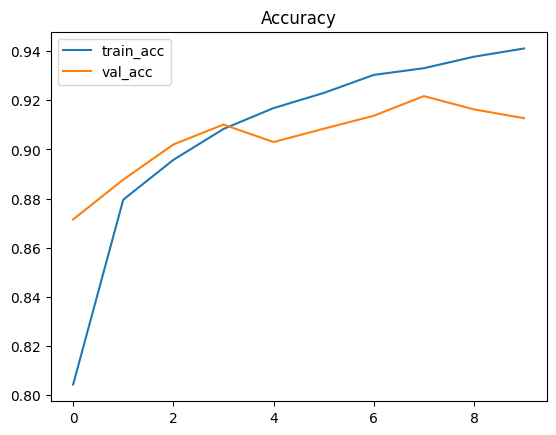

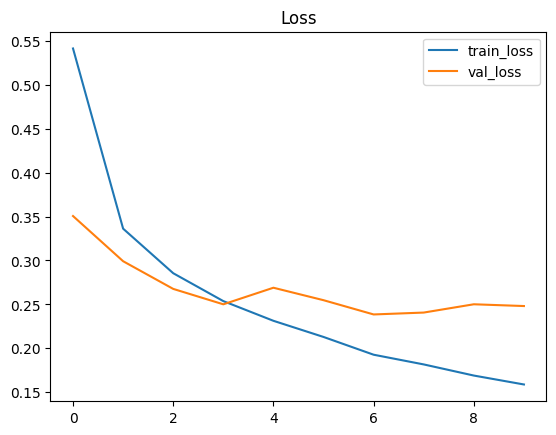

In [12]:




# -----------------------------
# PLOTS
# -----------------------------
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.legend()
plt.title("Accuracy")
plt.show()

plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.legend()
plt.title("Loss")
plt.show()



In [13]:
# -----------------------------
# MULTIPLE PREDICTIONS
# -----------------------------
for i in range(5):
    pred = final_model.predict(x_test[i:i+1])
    print("Predicted:", class_names[np.argmax(pred)],
          "| Actual:", class_names[y_test[i]])

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 595ms/step
Predicted: Ankle boot | Actual: Ankle boot
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
Predicted: Pullover | Actual: Pullover
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
Predicted: Trouser | Actual: Trouser
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
Predicted: Trouser | Actual: Trouser
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
Predicted: Shirt | Actual: Shirt
